# Loan Default Prediction & Credit Risk Analysis

## Project Overview

This project uses machine learning to predict whether a loan is likely to be fully paid or charged off.

The analysis builds on the earlier Power BI analysis of the same loan dataset. The Power BI project focused on understanding historical loan performance and credit risk patterns, while this project focuses on using machine learning to predict loan outcomes.

### Objectives

- Understand the loan dataset and its characteristics
- Identify and address data quality issues
- Explore factors associated with loan charge-offs
- Prepare the data for machine learning
- Build and compare classification models
- Evaluate model performance using appropriate classification metrics
- Apply the selected model to the provided test dataset
- Translate model findings into meaningful credit-risk insights

## 1. Import Libraries

The following Python libraries are used throughout the project:

- **Pandas** – data loading, cleaning, and manipulation
- **NumPy** – numerical operations
- **Matplotlib** – data visualization
- **Seaborn** – statistical visualization
- **Scikit-learn** – data preprocessing, machine learning models, and model evaluation

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## 2. Load the Datasets

Two datasets are provided for this project:

- **Training dataset (`credit_train.csv`)** – contains the loan features and the target variable, `Loan Status`. This dataset will be used for data analysis, preprocessing, model training, and validation.
- **Test dataset (`credit_test.csv`)** – contains the loan features but does not include `Loan Status`. It will be used only after the final model has been selected to generate predictions.

The test dataset will not be used during model training or model selection.

In [2]:
train = pd.read_csv("../data/credit_train.csv")
test = pd.read_csv("../data/credit_test.csv")

## 3. Initial Data Understanding

Before performing any cleaning or modeling, it is important to understand the structure of the training dataset.

We will examine:

- Number of rows and columns
- Data types
- Missing values
- Target variable
- Numerical and categorical variables

This initial inspection helps identify potential data-quality issues before preprocessing.

In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 100514 entries, 0 to 100513
Data columns (total 19 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Loan ID                       100000 non-null  str    
 1   Customer ID                   100000 non-null  str    
 2   Loan Status                   100000 non-null  str    
 3   Current Loan Amount           100000 non-null  float64
 4   Term                          100000 non-null  str    
 5   Credit Score                  80846 non-null   float64
 6   Annual Income                 80846 non-null   float64
 7   Years in current job          95778 non-null   str    
 8   Home Ownership                100000 non-null  str    
 9   Purpose                       100000 non-null  str    
 10  Monthly Debt                  100000 non-null  float64
 11  Years of Credit History       100000 non-null  float64
 12  Months since last delinquent  46859 non-null   float64


## 3.1 Dataset Dimensions and Sample Records

Before performing data cleaning, we will inspect the size and structure of both datasets.

We will check:

- The number of rows and columns in the training dataset
- The number of rows and columns in the test dataset
- The first few records of the training dataset

This helps us confirm that the datasets were loaded correctly and provides an initial view of the available variables.

In [4]:
print("Training dataset shape:", train.shape)
print("Test dataset shape:", test.shape)

train.head()

Training dataset shape: (100514, 19)
Test dataset shape: (10353, 18)


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


### Remarks

The training dataset contains the target variable `Loan Status`, which will be used as the prediction target during model development.

The test dataset will be kept separate from model training and will only be used for final predictions after the model has been selected.

The dataset also contains missing values that will need to be investigated and handled appropriately before machine learning.

## 3.2 Missing Values and Blank Records

The initial dataset inspection shows that several variables contain missing values.

Before deciding how to handle them, we need to determine:

- How many missing values are present in each column
- Whether the additional 514 rows contain useful information or are completely blank
- Which variables have substantial missingness

This step is important because inappropriate handling of missing values can affect both model training and prediction performance.

In [5]:
# Check missing values in the training dataset
missing_values = train.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Months since last delinquent    53655
Annual Income                   19668
Credit Score                    19668
Years in current job             4736
Bankruptcies                      718
Tax Liens                         524
Maximum Open Credit               516
Loan Status                       514
Customer ID                       514
Loan ID                           514
Term                              514
Monthly Debt                      514
Purpose                           514
Home Ownership                    514
Current Loan Amount               514
Number of Credit Problems         514
Number of Open Accounts           514
Years of Credit History           514
Current Credit Balance            514
dtype: int64

In [6]:
# Check how many completely blank rows are present
blank_rows = train.isnull().all(axis=1).sum()

print("Completely blank rows:", blank_rows)

Completely blank rows: 514


## 3.3 Handling Completely Blank Records

The training dataset contains 514 completely blank rows.

These records do not contain any loan, customer, financial, or credit information and therefore cannot contribute to either analysis or model training.

We will remove only the completely blank rows at this stage.

Other rows containing partial missing values will be retained and handled separately during the data-preprocessing stage.

In [7]:
# Remove completely blank rows
train = train.dropna(how="all").copy()

print("Training dataset shape after removing blank rows:", train.shape)

Training dataset shape after removing blank rows: (100000, 19)


## 4. Target Variable Analysis

The target variable for this classification problem is `Loan Status`.

It represents the outcome of a loan:

- **Fully Paid** – the loan was fully repaid.
- **Charged Off** – the loan was charged off.

Before building a machine learning model, we need to understand the distribution of these two classes.

This is important because an imbalanced target variable can make accuracy misleading. Therefore, model evaluation will later consider metrics such as precision, recall, F1-score, and ROC-AUC.

In [8]:
# Check the distribution of the target variable
train["Loan Status"].value_counts()

Loan Status
Fully Paid     77361
Charged Off    22639
Name: count, dtype: int64

In [9]:
# Check the percentage distribution of each target class
train["Loan Status"].value_counts(normalize=True) * 100

Loan Status
Fully Paid     77.361
Charged Off    22.639
Name: proportion, dtype: float64

### Remarks

The target variable is moderately imbalanced, with 77.36% Fully Paid loans and 22.64% Charged Off loans.

Therefore, accuracy alone may not provide a complete picture of model performance. Precision, recall, F1-score, and ROC-AUC will also be considered during model evaluation.

## 4.1 Target Variable Distribution

A bar chart is used to visualize the distribution of the target classes.

Visualizing the target variable makes the class imbalance easier to identify and provides a useful reference before model training.

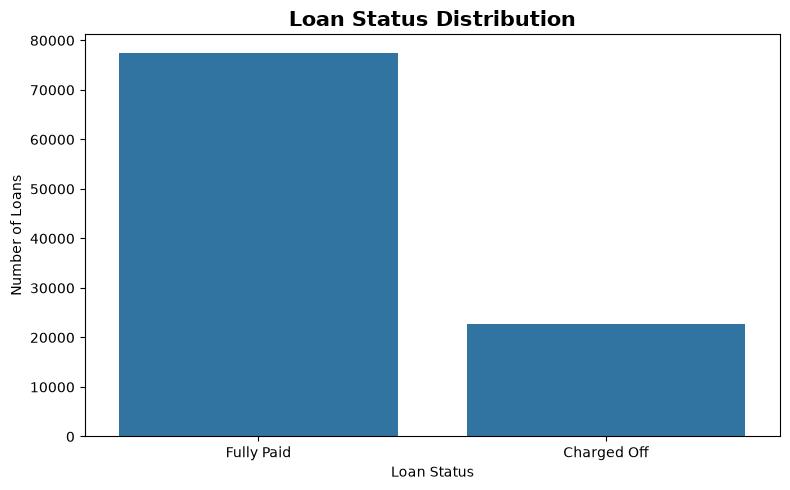

In [14]:
# Visualize the target variable distribution

status_counts = train["Loan Status"].value_counts()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=status_counts.index,
    y=status_counts.values
)

plt.title("Loan Status Distribution", fontsize=15, fontweight="bold")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.tight_layout()

plt.savefig("../Images/loan_status_distribution.png")

plt.show()

## 4.2 Numerical Feature Analysis

We will examine the main numerical variables using descriptive statistics.

The `describe()` method provides information such as the count, mean, standard deviation, minimum, maximum, and quartile values.

This gives us an initial understanding of the distribution and scale of the numerical features before preprocessing.

In [17]:
# Display descriptive statistics for numerical variables

train.describe().T

,count,mean,std,min,25%,50%,75%,max
Current Loan Amount,100000.0,1.176045e+07,3.178394e+07,10802.0,179652.0000,312246.0,5.249420e+05,1.000000e+08
Credit Score,80846.0,1.076456e+03,1.475404e+03,585.0,705.0000,724.0,7.410000e+02,7.510000e+03
Annual Income,80846.0,1.378277e+06,1.081360e+06,76627.0,848844.0000,1174162.0,1.650663e+06,1.655574e+08
Monthly Debt,100000.0,1.847241e+04,1.217499e+04,0.0,10214.1625,16220.3,2.401206e+04,4.358433e+05
Years of Credit History,100000.0,1.819914e+01,7.015324e+00,3.6,13.5000,16.9,2.170000e+01,7.050000e+01
Months since last delinquent,46859.0,3.490132e+01,2.199783e+01,0.0,16.0000,32.0,5.100000e+01,1.760000e+02
Number of Open Accounts,100000.0,1.112853e+01,5.009870e+00,0.0,8.0000,10.0,1.400000e+01,7.600000e+01
Number of Credit Problems,100000.0,1.683100e-01,4.827050e-01,0.0,0.0000,0.0,0.000000e+00,1.500000e+01
Current Credit Balance,100000.0,2.946374e+05,3.761709e+05,0.0,112670.0000,209817.0,3.679588e+05,3.287897e+07
Maximum Open Credit,99998.0,7.607984e+05,8.384503e+06,0.0,273438.0000,467874.0,7.829580e+05,1.539738e+09


## 4.3 Investigating Unusual Numerical Values

Descriptive statistics show that some numerical variables contain unusually large or potentially invalid values.

We will investigate these values before preprocessing to determine whether they represent genuine observations, data-entry issues, or values that require further treatment.

In [18]:
# Check credit scores above 850

high_credit_scores = train[train["Credit Score"] > 850]

print("Number of credit scores above 850:", len(high_credit_scores))

Number of credit scores above 850: 4551


In [19]:
# Inspect the credit score values above 850

train.loc[train["Credit Score"] > 850, "Credit Score"].describe()

count    4551.000000
mean     7108.989233
std       306.627221
min      5850.000000
25%      6950.000000
50%      7190.000000
75%      7350.000000
max      7510.000000
Name: Credit Score, dtype: float64

In [20]:
# Compare unusual credit scores with values after dividing by 10

train.loc[
    train["Credit Score"] > 850,
    "Credit Score"
].head(10)

5      7290.0
43     7120.0
51     6610.0
56     7380.0
65     7370.0
97     6240.0
117    7210.0
160    7500.0
165    7020.0
200    7080.0
Name: Credit Score, dtype: float64

In [21]:
# Check whether all unusual credit scores become valid after dividing by 10

scaled_scores = train.loc[
    train["Credit Score"] > 850,
    "Credit Score"
] / 10

print("Minimum scaled score:", scaled_scores.min())
print("Maximum scaled score:", scaled_scores.max())

Minimum scaled score: 585.0
Maximum scaled score: 751.0


### Correcting Credit Score Scale

The investigation shows that credit scores above 850 are recorded at approximately 10 times their expected scale.

For the 4,551 affected records, the values will be divided by 10 to restore them to the same scale as the other credit scores.

Only values above 850 will be modified; the remaining credit scores will be left unchanged.

In [22]:
# Correct credit scores that are recorded at 10 times their expected scale

train.loc[train["Credit Score"] > 850, "Credit Score"] = (
    train.loc[train["Credit Score"] > 850, "Credit Score"] / 10
)

In [23]:
# Check the credit score range after correction

train["Credit Score"].describe()

count    80846.000000
mean       716.293447
std         28.297164
min        585.000000
25%        703.000000
50%        722.000000
75%        738.000000
max        751.000000
Name: Credit Score, dtype: float64

In [26]:
# Compare the minimum and maximum values of numerical variables

train.select_dtypes(include="number").agg(["min", "max"]).T

,min,max
Current Loan Amount,10802.0,1.000000e+08
Credit Score,585.0,7.510000e+02
Annual Income,76627.0,1.655574e+08
Monthly Debt,0.0,4.358433e+05
Years of Credit History,3.6,7.050000e+01
Months since last delinquent,0.0,1.760000e+02
Number of Open Accounts,0.0,7.600000e+01
Number of Credit Problems,0.0,1.500000e+01
Current Credit Balance,0.0,3.287897e+07
Maximum Open Credit,0.0,1.539738e+09


In [31]:
# e+ notation is a scientific notation. 
# If we want the output displayed as normal numbers, we can change pandas' display format.

pd.set_option("display.float_format", "{:,.2f}".format)

In [32]:
train.select_dtypes(include="number").agg(["min", "max"]).T

,min,max
Current Loan Amount,"10,802.00","99,999,999.00"
Credit Score,585.00,751.00
Annual Income,"76,627.00","165,557,393.00"
Monthly Debt,0.00,"435,843.28"
Years of Credit History,3.60,70.50
Months since last delinquent,0.00,176.00
Number of Open Accounts,0.00,76.00
Number of Credit Problems,0.00,15.00
Current Credit Balance,0.00,"32,878,968.00"
Maximum Open Credit,0.00,"1,539,737,892.00"


## 4.4 Investigating Current Loan Amount

The `Current Loan Amount` variable has a very large maximum value compared with its typical values.

We will inspect its distribution and extreme values before deciding whether any treatment is necessary.

In [33]:
# Inspect the distribution of Current Loan Amount

train["Current Loan Amount"].describe()

count      100,000.00
mean    11,760,447.39
std     31,783,942.55
min         10,802.00
25%        179,652.00
50%        312,246.00
75%        524,942.00
max     99,999,999.00
Name: Current Loan Amount, dtype: float64

In [34]:
# Count very large loan amounts

large_loans = train[train["Current Loan Amount"] > 1000000]

print("Number of loan amounts above $1 million:", len(large_loans))

Number of loan amounts above $1 million: 11484


In [38]:
# Inspect the largest loan amounts

train["Current Loan Amount"].nlargest(15)

2     99,999,999.00
10    99,999,999.00
12    99,999,999.00
13    99,999,999.00
26    99,999,999.00
28    99,999,999.00
30    99,999,999.00
36    99,999,999.00
54    99,999,999.00
72    99,999,999.00
79    99,999,999.00
80    99,999,999.00
87    99,999,999.00
114   99,999,999.00
119   99,999,999.00
Name: Current Loan Amount, dtype: float64

In [39]:
# Count records with the maximum placeholder value

placeholder_loans = (train["Current Loan Amount"] == 99999999).sum()

print("Number of records with Current Loan Amount = $99,999,999:", placeholder_loans)

Number of records with Current Loan Amount = $99,999,999: 11484


### Handling the Current Loan Amount Placeholder

The value `99,999,999` appears in 11,484 records and represents a placeholder rather than a realistic loan amount.

We will replace this value with `NaN` so that it can be handled as a missing value during the preprocessing stage.

In [40]:
# Replace the placeholder value with a missing value

train["Current Loan Amount"] = train["Current Loan Amount"].replace(99999999, np.nan)

In [41]:
# Check the number of missing loan amounts

train["Current Loan Amount"].isnull().sum()

np.int64(11484)

## 4.5 Investigating Annual Income

The `Annual Income` variable also has a very large maximum value compared with its typical values.

We will inspect its descriptive statistics and extreme values before deciding whether any treatment is required.

In [42]:
# Inspect the distribution of Annual Income

train["Annual Income"].describe()

count        80,846.00
mean      1,378,276.56
std       1,081,360.20
min          76,627.00
25%         848,844.00
50%       1,174,162.00
75%       1,650,663.00
max     165,557,393.00
Name: Annual Income, dtype: float64

In [43]:
# Inspect the largest annual income values

train["Annual Income"].nlargest(10)

85662   165,557,393.00
37858    36,475,440.00
10721    30,838,995.00
58682    28,095,300.00
21598    24,161,540.00
25003    23,980,375.00
29203    22,448,880.00
30665    22,448,880.00
62057    19,019,000.00
40801    18,768,200.00
Name: Annual Income, dtype: float64

In [46]:
# Count very high annual income values

high_income = (train["Annual Income"] > 10000000).sum()

print("Number of records with Annual Income above $10 million:", high_income)

Number of records with Annual Income above $10 million: 68


### Remarks

Only 68 records have an Annual Income above $10 million. Since the values are varied rather than a repeated placeholder, they will be retained and handled during preprocessing if necessary.

## 4.6 Investigating Current Credit Balance

The `Current Credit Balance` variable has a large range of values.

We will inspect its descriptive statistics and extreme values to determine whether any data-quality issues are present.

In [47]:
# Inspect the distribution of Current Credit Balance

train["Current Credit Balance"].describe()

count      100,000.00
mean       294,637.38
std        376,170.93
min              0.00
25%        112,670.00
50%        209,817.00
75%        367,958.75
max     32,878,968.00
Name: Current Credit Balance, dtype: float64

In [48]:
# Inspect the largest current credit balances

train["Current Credit Balance"].nlargest(10)

15837   32,878,968.00
45497   12,986,956.00
50909   12,986,956.00
67718   12,746,397.00
82364   12,746,397.00
96221   11,796,435.00
51445   11,361,924.00
27289    9,134,592.00
45952    9,134,592.00
60699    7,888,952.00
Name: Current Credit Balance, dtype: float64

In [49]:
# Calculate the IQR-based outlier threshold for Current Credit Balance

Q1 = train["Current Credit Balance"].quantile(0.25)
Q3 = train["Current Credit Balance"].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR
lower_limit = Q3 - 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper outlier limit:", upper_limit)
print("Lower outlier limit:", lower_limit)

Q1: 112670.0
Q3: 367958.75
IQR: 255288.75
Upper outlier limit: 750891.875
Lower outlier limit: -14974.375


> Since a credit balance cannot realistically be negative, the lower limit isn't important here.

In [50]:
# Count Current Credit Balance values above the IQR outlier limit

credit_balance_outliers = (
    train["Current Credit Balance"] > upper_limit
).sum()

print("Number of Current Credit Balance outliers:", credit_balance_outliers)

Number of Current Credit Balance outliers: 5184


### Remarks

The IQR method identifies 5,184 unusually high credit-balance values. These observations will be retained because they may represent genuine financial behavior rather than data-entry errors.

## 4.7 Checking Duplicate Records

Duplicate records can affect machine learning evaluation if identical observations are present in both the training and validation sets.

We will identify and remove exact duplicate rows before splitting the data for model development.

In [51]:
# Check for duplicate rows

duplicate_rows = train.duplicated().sum()

print("Number of duplicate rows:", duplicate_rows)

Number of duplicate rows: 10215


### Removing Exact Duplicate Records

The training dataset contains 10,215 exact duplicate rows.

Because these records contain identical values across all columns, keeping them could give repeated observations disproportionate influence during model training.

The duplicate rows will be removed while keeping the first occurrence of each record.

In [52]:
# Remove exact duplicate rows

train = train.drop_duplicates().copy()

print("Training dataset shape after removing duplicates:", train.shape)

Training dataset shape after removing duplicates: (89785, 19)


In [53]:
# Check the target distribution after data cleaning

train["Loan Status"].value_counts(normalize=True) * 100

Loan Status
Fully Paid    74.79
Charged Off   25.21
Name: proportion, dtype: float64

### Remarks

After removing duplicate records, the target distribution is 74.79% Fully Paid and 25.21% Charged Off.

The dataset remains moderately imbalanced, so model evaluation should consider precision, recall, F1-score, and ROC-AUC rather than accuracy alone.

## 4.8 Final Missing Value Check

After the initial data cleaning and treatment of placeholder values, we will review the remaining missing values in the training dataset.

This will help us determine which variables require imputation during preprocessing.

In [54]:
# Check remaining missing values

missing_values = train.isnull().sum()

missing_values[missing_values > 0].sort_values(ascending=False)

Months since last delinquent    48337
Credit Score                    19154
Annual Income                   19154
Current Loan Amount             11484
Years in current job             3802
Bankruptcies                      190
Tax Liens                           9
Maximum Open Credit                 2
dtype: int64

### Remarks

Several variables contain missing values, with `Months since last delinquent` having the highest level of missingness.

Missing values will be handled during preprocessing using appropriate strategies based on the type and meaning of each variable.

In [56]:
# Calculate the percentage of missing values

missing_percentage = train.isnull().mean() * 100

missing_percentage[missing_percentage > 0].sort_values(ascending=False)

Months since last delinquent   53.84
Credit Score                   21.33
Annual Income                  21.33
Current Loan Amount            12.79
Years in current job            4.23
Bankruptcies                    0.21
Tax Liens                       0.01
Maximum Open Credit             0.00
dtype: float64

## 4.9 Investigating Months Since Last Delinquent

`Months since last delinquent` contains more than half missing values.

We will first determine whether missingness is related to the loan status before deciding how this variable should be handled.

In [57]:
# Compare missingness in Months since last delinquent by loan status

train.groupby("Loan Status")["Months since last delinquent"].apply(
    lambda x: x.isnull().mean() * 100
)

Loan Status
Charged Off   54.02
Fully Paid    53.77
Name: Months since last delinquent, dtype: float64

### Remarks

Missingness in `Months since last delinquent` is very similar across the two loan-status groups: 54.02% for Charged Off loans and 53.77% for Fully Paid loans.

The variable will be retained, with its missing values handled during preprocessing.

## 4.10 Identifying Feature Types

Before preprocessing the data, we will separate the predictor variables into numerical and categorical features.

Numerical features will require numerical preprocessing, while categorical features will need to be converted into a machine-readable format.

In [61]:
# Identify numerical and categorical columns

numerical_features = train.select_dtypes(include="number").columns.tolist()
categorical_features = train.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Current Loan Amount', 'Credit Score', 'Annual Income', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']

Categorical features:
['Loan ID', 'Customer ID', 'Loan Status', 'Term', 'Years in current job', 'Home Ownership', 'Purpose']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3920\2555133167.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = train.select_dtypes(include="object").columns.tolist()


## 4.11 Identifying Identifier Columns

`Loan ID` and `Customer ID` are identifiers rather than meaningful predictive features.

We will check their uniqueness before excluding them from the machine learning features.

In [62]:
# Check the number of unique values in the identifier columns

print("Unique Loan IDs:", train["Loan ID"].nunique())
print("Unique Customer IDs:", train["Customer ID"].nunique())
print("Total rows:", len(train))

Unique Loan IDs: 81999
Unique Customer IDs: 81999
Total rows: 89785


In [63]:
# Check how many customers have multiple loan records

customer_counts = train["Customer ID"].value_counts()

print("Customers with multiple loan records:", (customer_counts > 1).sum())
print("Maximum loan records for one customer:", customer_counts.max())

Customers with multiple loan records: 7786
Maximum loan records for one customer: 2


## 4.12 Investigating Repeated Loan IDs

Some `Loan ID` values occur more than once after removing exact duplicate rows.

We will investigate these repeated loan records to determine whether they represent multiple versions of the same loan or legitimate repeated observations.

In [64]:
# Count repeated Loan IDs

loan_id_counts = train["Loan ID"].value_counts()

print("Loan IDs with multiple records:", (loan_id_counts > 1).sum())
print("Maximum records for one Loan ID:", loan_id_counts.max())

Loan IDs with multiple records: 7786
Maximum records for one Loan ID: 2


In [67]:
# Inspect records with repeated Loan IDs

repeated_loan_ids = loan_id_counts[loan_id_counts > 1].index

train[train["Loan ID"].isin(repeated_loan_ids)].head(10)

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,"176,220.00",Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,"20,639.70",6.10,NaN,15.00,0.00,"253,460.00","427,174.00",0.00,0.00
8,8af915d9-9e91-44a0-b5a2-564a45c12089,af534dea-d27e-4fd6-9de8-efaa52a78ec0,Fully Paid,"548,746.00",Short Term,678.00,"2,559,110.00",2 years,Rent,Debt Consolidation,"18,660.28",22.60,33.00,4.00,0.00,"437,171.00","555,038.00",0.00,0.00
15,7cbaa3fa-16fd-4343-9bcb-e90b34a1072f,3ec886e7-f15d-4c35-83d0-bdec4817ae4b,Fully Paid,"449,020.00",Long Term,NaN,NaN,9 years,Own Home,Debt Consolidation,"18,904.81",19.40,NaN,8.00,0.00,"334,533.00","428,956.00",0.00,0.00
24,7aa649ff-b73b-4556-a4c3-a4d35762809a,54f57722-2473-4dd8-b69b-82b5b0c1c9f9,Fully Paid,"244,926.00",Long Term,704.00,"1,249,953.00",4 years,Home Mortgage,Debt Consolidation,"6,812.26",14.40,NaN,6.00,1.00,"143,051.00","245,014.00",0.00,1.00
26,0c14cb77-29a3-4964-9198-0c43f5f982b0,9baf6d5d-f744-4332-abb0-e939b75cde40,Fully Paid,NaN,Short Term,724.00,"1,029,857.00",1 year,Rent,Debt Consolidation,"13,817.18",12.00,NaN,6.00,0.00,"138,339.00","221,232.00",0.00,0.00
33,af76ed30-e663-4125-8749-3ff5e509cb37,61a4f1ed-e2c3-401e-aec8-9b0d7178f5ff,Fully Paid,"333,564.00",Long Term,725.00,"1,248,338.00",10+ years,Home Mortgage,Debt Consolidation,"18,205.04",14.60,NaN,18.00,0.00,"300,979.00","515,526.00",0.00,0.00
42,dc17c812-a350-459f-84dd-906fd42a5ab2,847e2dfa-a44c-4ec1-b05f-5d4a33e66885,Fully Paid,"327,008.00",Long Term,NaN,NaN,4 years,Home Mortgage,Debt Consolidation,"15,419.45",16.70,24.00,13.00,0.00,"268,090.00","529,738.00",0.00,0.00
48,17d0f2ec-c03f-4885-91a8-aa90830372b5,6cfb0765-7cd8-4ef5-aa6e-f935caf57cf0,Fully Paid,"439,428.00",Short Term,710.00,"1,518,024.00",8 years,Rent,Debt Consolidation,"20,923.56",17.80,NaN,11.00,0.00,"209,304.00","265,716.00",0.00,0.00
50,56171b60-824e-46cf-8e39-3304427e84f4,86d02184-ce07-4f47-9f68-45743fa29ced,Fully Paid,"518,012.00",Long Term,719.00,"1,193,010.00",10+ years,Own Home,Debt Consolidation,"22,667.38",20.90,NaN,11.00,0.00,"452,770.00","1,080,926.00",0.00,0.00
57,f8dcf551-d7b6-4378-8a29-caa1b0a42e75,b6f9e737-6609-45fd-8d6c-37b1b64c45df,Fully Paid,"669,372.00",Short Term,725.00,"2,158,210.00",7 years,Home Mortgage,Debt Consolidation,"34,711.29",9.20,NaN,17.00,0.00,"496,052.00","638,176.00",0.00,0.00


### Checking for Conflicting Loan Statuses

Because some Loan IDs appear more than once, we need to check whether the same Loan ID is associated with different loan outcomes.

If a Loan ID has both `Fully Paid` and `Charged Off` records, it may represent different versions or stages of the same loan and requires further investigation.

In [68]:
# Check whether any Loan ID has more than one loan status

loan_status_counts = train.groupby("Loan ID")["Loan Status"].nunique()

conflicting_loan_ids = (loan_status_counts > 1).sum()

print("Loan IDs with conflicting loan statuses:", conflicting_loan_ids)

Loan IDs with conflicting loan statuses: 0


### Remarks

No Loan ID is associated with conflicting loan statuses.

The repeated Loan IDs therefore do not appear to create target-label inconsistencies. Since these records may represent legitimate repeated observations, they will be retained in the dataset.

The Loan ID and Customer ID columns will still be excluded from the machine learning features because they are identifiers rather than predictive variables.

## 4.13 Separating Target and Predictor Variables

The target variable is `Loan Status`, which represents the loan outcome we want to predict.

We will separate it from the predictor variables before beginning machine learning preprocessing.

The identifier columns `Loan ID` and `Customer ID` will also be excluded because they identify records or customers rather than provide meaningful predictive information.

In [74]:
# Separate the target variable from the predictor variables

X = train.drop(columns=["Loan Status", "Loan ID", "Customer ID"])
y = train["Loan Status"]

print("Feature dataset shape:", X.shape)
print("Target dataset shape:", y.shape)

Feature dataset shape: (89785, 16)
Target dataset shape: (89785,)


## 4.14 Encoding the Target Variable

Machine learning classification models require the target variable to be represented numerically.

We will encode:

- **Fully Paid** → 0
- **Charged Off** → 1

Using 1 for `Charged Off` makes the positive class represent the loan outcome we are interested in identifying as a potential credit-risk event.

In [75]:
# Encode the target variable

y = y.map({
    "Fully Paid": 0,
    "Charged Off": 1
})

print(y.value_counts(normalize=True) * 100)

Loan Status
0   74.79
1   25.21
Name: proportion, dtype: float64


### Remarks

The target variable has been successfully encoded as 0 and 1.

The class distribution remains moderately imbalanced, with 74.79% Fully Paid loans and 25.21% Charged Off loans. This imbalance will be considered when evaluating the classification models.

## 5. Train-Validation Split

The cleaned dataset will be divided into training and validation sets.

- **80%** of the data will be used for model training.
- **20%** will be used for validation.
- `stratify=y` will preserve the proportion of Fully Paid and Charged Off loans in both sets.

The validation data will remain unseen during model training and preprocessing.

In [76]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Validation features:", X_valid.shape)
print("Training target:", y_train.shape)
print("Validation target:", y_valid.shape)

Training features: (71828, 16)
Validation features: (17957, 16)
Training target: (71828,)
Validation target: (17957,)


## 5.1 Checking Target Distribution After the Split

Because the target variable is moderately imbalanced, we used stratified sampling when creating the training and validation sets.

We will now compare the target distribution in both sets to confirm that the class proportions have been preserved.

In [77]:
# Compare target distribution in training and validation sets

print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True) * 100)

Training target distribution:
Loan Status
0   74.79
1   25.21
Name: proportion, dtype: float64

Validation target distribution:
Loan Status
0   74.78
1   25.22
Name: proportion, dtype: float64


### Remarks

The target proportions are almost identical in the training and validation sets.

This confirms that stratified splitting successfully preserved the original class distribution.

## 6. Feature Preprocessing

The predictor variables contain both numerical and categorical features.

Numerical features will be imputed for missing values, while categorical features will be imputed and encoded into a numerical format suitable for machine learning models.

In [78]:
# Identify numerical and categorical features

numerical_features = X_train.select_dtypes(include="number").columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Current Loan Amount', 'Credit Score', 'Annual Income', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']

Categorical features:
['Term', 'Years in current job', 'Home Ownership', 'Purpose']


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_3920\3176335823.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(include="object").columns.tolist()


## 6.1 Creating the Preprocessing Pipeline

The numerical and categorical features require different preprocessing steps.

For numerical features:
- Missing values will be replaced using the median.
- Values will be standardized to a similar scale.

For categorical features:
- Missing values will be replaced using the most frequent category.
- Categories will be converted into numerical features using one-hot encoding.

The preprocessing will be fitted only on the training data to avoid data leakage.

In [79]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Preprocessing for numerical features

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [80]:
# Combine numerical and categorical preprocessing

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

### Remarks

The preprocessing pipeline is designed to handle missing values, scale numerical features, and encode categorical features.

The `ColumnTransformer` combines both preprocessing pipelines and applies each one to the appropriate columns.

## 6.2 Applying the Preprocessing Pipeline

The preprocessing pipeline will now be fitted using the training data and then applied to both the training and validation datasets.

The pipeline is fitted only on the training data to prevent information from the validation set from influencing the preprocessing.

In [81]:
# Fit the preprocessing pipeline on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the fitted pipeline to the validation data
X_valid_processed = preprocessor.transform(X_valid)

print("Processed training data shape:", X_train_processed.shape)
print("Processed validation data shape:", X_valid_processed.shape)

Processed training data shape: (71828, 45)
Processed validation data shape: (17957, 45)


### Remarks

The preprocessing pipeline transformed the original 16 predictor variables into 45 machine-learning-ready features.

The same fitted preprocessing steps were applied to both training and validation data, while the validation data remained unseen during fitting.

## 6.3 Checking the Processed Data

We will verify that the preprocessing step has handled missing values and converted the categorical variables into numerical features.

This check helps confirm that the data is ready for model training.

In [82]:
# Check for missing values in the processed training data
print("Missing values in processed training data:", np.isnan(X_train_processed).sum())

Missing values in processed training data: 0


### Remarks

The processed training data contains no missing values.

The preprocessing pipeline has successfully imputed missing values and converted the predictor variables into a numerical format suitable for machine learning.

## 6.4 Checking the Number of Processed Features

One-hot encoding expands categorical variables into multiple binary features.

We will check the final number of features after preprocessing.

In [83]:
# Check the number of features after preprocessing

print("Number of processed features:", X_train_processed.shape[1])

Number of processed features: 45


### Remarks

The preprocessing step expanded the original 16 predictor variables into 45 numerical features through one-hot encoding of categorical variables.

The processed dataset is now ready for machine learning model training.

# 7. Model Training

The preprocessed data is now ready for machine learning.

We will train classification models to predict whether a loan will be **Fully Paid (0)** or **Charged Off (1)**.

The models will be trained using the training data and evaluated on the validation data.

## 7.1 Logistic Regression

Logistic Regression is used as the baseline classification model for predicting loan outcomes.

It estimates the probability that a loan belongs to the **Charged Off (1)** class based on the available predictor variables.

In [84]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Remarks

The Logistic Regression model was successfully trained on the preprocessed training data without convergence warnings.

This model will serve as the baseline for comparison with other classification models.

## 7.2 Making Predictions with Logistic Regression

The trained Logistic Regression model will now be used to predict loan outcomes for the validation dataset.

These predictions will later be compared with the actual loan outcomes to evaluate model performance.

In [85]:
# Make predictions on the validation data
y_pred_logistic = logistic_model.predict(X_valid_processed)

print("Predictions generated successfully.")

Predictions generated successfully.


### Remarks

The Logistic Regression model successfully generated predictions for all validation records.

These predictions will be compared with the actual validation outcomes to measure the model's performance.

## 7.3 Evaluating Logistic Regression

We will evaluate the Logistic Regression model using accuracy, precision, recall, and F1-score.

These metrics provide a more complete view of model performance, especially because the target variable is moderately imbalanced.

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate classification metrics
accuracy = accuracy_score(y_valid, y_pred_logistic)
precision = precision_score(y_valid, y_pred_logistic)
recall = recall_score(y_valid, y_pred_logistic)
f1 = f1_score(y_valid, y_pred_logistic)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7491785933062316
Precision: 0.5487804878048781
Recall: 0.029814487632508834
F1-score: 0.05655634687892752


### Remarks

The Logistic Regression model achieved 74.92% accuracy, but its recall for the Charged Off class was only 2.98%.

This indicates that the baseline model is missing most charged-off loans. Therefore, accuracy alone is not sufficient for this credit-risk problem.

Further model evaluation and comparison are required to identify a model that can better detect charged-off loans.

## 7.4 Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions for each loan-status class.

It will help us understand how well the Logistic Regression model identifies Fully Paid and Charged Off loans.

In [87]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm = confusion_matrix(y_valid, y_pred_logistic)

print(cm)

[[13318   111]
 [ 4393   135]]


### Remarks

The confusion matrix shows that the Logistic Regression model correctly identified 135 Charged Off loans but incorrectly classified 4,393 Charged Off loans as Fully Paid.

This confirms that the baseline model has very low ability to detect the risk class and that further model improvement is necessary.

## 7.5 Random Forest

Random Forest is an ensemble classification model that combines multiple decision trees to make predictions.

It can capture non-linear relationships between loan characteristics and loan outcomes.

We will train a Random Forest model and compare its performance with the Logistic Regression baseline.

In [88]:
from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### Remarks

Random Forest was trained successfully using 100 decision trees with balanced class weighting to improve the detection of Charged Off loans.

## 7.6 Making Predictions with Random Forest

The trained Random Forest model will now be used to predict loan outcomes for the validation dataset.

These predictions will be compared with the actual loan outcomes to evaluate the model's performance.

In [89]:
# Make predictions on the validation data

y_pred_rf = random_forest_model.predict(X_valid_processed)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


### Remarks

The Random Forest model generated predictions for all 17,957 validation records. These predictions will be used to evaluate the model's classification performance.

## 7.7 Evaluating Random Forest

The Random Forest model will be evaluated using accuracy, precision, recall, and F1-score.

These metrics will be compared with the Logistic Regression results to determine which model better identifies Charged Off loans.

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate Random Forest classification metrics
accuracy_rf = accuracy_score(y_valid, y_pred_rf)
precision_rf = precision_score(y_valid, y_pred_rf)
recall_rf = recall_score(y_valid, y_pred_rf)
f1_rf = f1_score(y_valid, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Accuracy: 0.7290193239405246
Precision: 0.44705513784461154
Recall: 0.31515017667844525
F1-score: 0.36968911917098446


### Remarks

Random Forest achieved 72.90% accuracy, 44.71% precision, 31.52% recall, and a 36.97% F1-score.

Compared with Logistic Regression, Random Forest substantially improved recall and F1-score, indicating better detection of Charged Off loans, although its accuracy and precision were lower.

## 7.8 Random Forest Confusion Matrix

The confusion matrix provides a detailed view of how the Random Forest model classified Fully Paid and Charged Off loans.

It shows the number of correct and incorrect predictions for each class.

In [91]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix
cm_rf = confusion_matrix(y_valid, y_pred_rf)

print(cm_rf)

[[11664  1765]
 [ 3101  1427]]


### Remarks

The Random Forest model correctly identified 1,427 Charged Off loans, while 3,101 Charged Off loans were incorrectly classified as Fully Paid.

This indicates that Random Forest detects more Charged Off loans than the Logistic Regression baseline, but a substantial number of risky loans are still missed.

## 7.9 Model Comparison

The Logistic Regression and Random Forest models will be compared using accuracy, precision, recall, and F1-score.

This comparison will help identify which model performs better at detecting Charged Off loans.

In [92]:
# Compare Logistic Regression and Random Forest

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.75,0.55,0.03,0.06
1,Random Forest,0.73,0.45,0.32,0.37


### Remarks

Random Forest achieved a higher recall and F1-score than Logistic Regression, indicating better performance in identifying Charged Off loans.

Although Logistic Regression had higher accuracy and precision, its very low recall shows that it missed most Charged Off loans.

For this credit-risk problem, Random Forest is the stronger model of the two based on recall and F1-score.

## 7.10 ROC-AUC Evaluation

ROC-AUC measures how well a classification model distinguishes between the two loan-status classes across different classification thresholds.

A higher ROC-AUC indicates better overall ability to distinguish Charged Off loans from Fully Paid loans.

In [93]:
from sklearn.metrics import roc_auc_score

# Generate predicted probabilities
y_prob_logistic = logistic_model.predict_proba(X_valid_processed)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_valid_processed)[:, 1]

# Calculate ROC-AUC
roc_auc_logistic = roc_auc_score(y_valid, y_prob_logistic)
roc_auc_rf = roc_auc_score(y_valid, y_prob_rf)

print("Logistic Regression ROC-AUC:", roc_auc_logistic)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 0.6382610467773583
Random Forest ROC-AUC: 0.7084193383761266


### Remarks

Random Forest achieved a ROC-AUC of 0.7084, compared with 0.6383 for Logistic Regression.

This indicates that Random Forest has better overall ability to distinguish between Fully Paid and Charged Off loans.

## 7.11 Final Model Selection

Based on the evaluation results, the Logistic Regression and Random Forest models will be compared to select the stronger model for this credit-risk prediction task.

Because identifying Charged Off loans is an important objective, recall, F1-score, and ROC-AUC will receive greater consideration than accuracy alone.

In [94]:
# Final comparison of the classification models

final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf],
    "ROC-AUC": [roc_auc_logistic, roc_auc_rf]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.75,0.55,0.03,0.06,0.64
1,Random Forest,0.73,0.45,0.32,0.37,0.71


### Remarks

Random Forest is selected as the stronger model for this credit-risk prediction task.

It achieved substantially higher recall, F1-score, and ROC-AUC than Logistic Regression, making it better suited to identifying Charged Off loans.

Although Logistic Regression achieved higher accuracy and precision, its very low recall indicates that it missed most Charged Off loans.

## 7.13 Feature Importance

Random Forest provides feature importance scores that indicate the relative contribution of each processed feature to the model's predictions.

The preprocessing pipeline created 45 machine-learning features, so the original categorical variables may appear as multiple one-hot encoded features.

We will identify the most important features used by the selected Random Forest model.

In [95]:
# Get the names of the processed features
feature_names = preprocessor.get_feature_names_out()

# Get feature importance scores from Random Forest
feature_importance = random_forest_model.feature_importances_

# Create a DataFrame of feature importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

# Sort features by importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,num__Current Loan Amount,0.15
9,num__Maximum Open Credit,0.10
3,num__Monthly Debt,0.10
8,num__Current Credit Balance,0.10
4,num__Years of Credit History,0.09
2,num__Annual Income,0.09
1,num__Credit Score,0.08
6,num__Number of Open Accounts,0.07
5,num__Months since last delinquent,0.06
15,cat__Years in current job_10+ years,0.01


### Remarks

Current Loan Amount is the most important processed feature in the Random Forest model, followed by Maximum Open Credit, Monthly Debt, and Current Credit Balance.

Several financial and credit-history variables contribute to the model's predictions, indicating that borrower financial characteristics play an important role in distinguishing loan outcomes.

## 7.14 Feature Importance Visualization

The top 10 features will be visualized using a horizontal bar chart.

This makes it easier to compare the relative importance of the features identified by the Random Forest model.

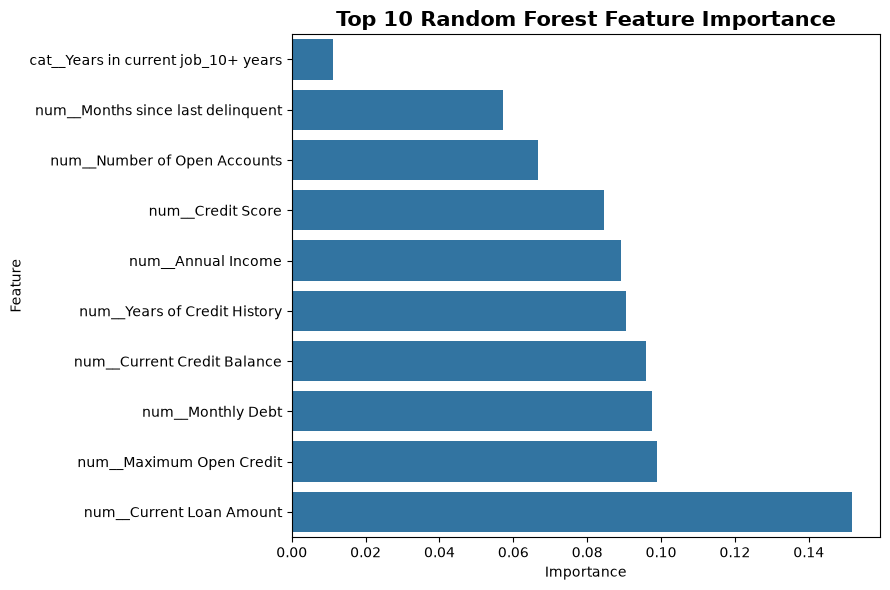

In [98]:
# Select the top 10 most important features
top_features = importance_df.head(10).sort_values(
    by="Importance"
)

# Create the feature importance chart
plt.figure(figsize=(9, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title("Top 10 Random Forest Feature Importance", fontsize=15, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("../Images/random_forest_feature_importance.png")

plt.show()

### Remarks

The Random Forest model assigns the highest feature importance to Current Loan Amount, followed by Maximum Open Credit, Monthly Debt, and Current Credit Balance.

These features contributed most to the model's predictions within this dataset. Feature importance indicates the features used most by the Random Forest model and does not imply a causal relationship with loan default.

## 7.15 Checking for Train-Validation Leakage

Some Loan IDs and Customer IDs occur more than once in the dataset.

Before relying on the validation results, we check whether the same Loan ID or Customer ID appears in both the training and validation sets.

If there is overlap, the validation performance may be optimistic because the model has seen records belonging to the same loan or customer during training.

In [99]:
# Check Loan ID overlap
loan_ids_train = set(train.loc[X_train.index, "Loan ID"])
loan_ids_valid = set(train.loc[X_valid.index, "Loan ID"])

loan_overlap = loan_ids_train.intersection(loan_ids_valid)

print("Overlapping Loan IDs:", len(loan_overlap))


# Check Customer ID overlap
customer_ids_train = set(train.loc[X_train.index, "Customer ID"])
customer_ids_valid = set(train.loc[X_valid.index, "Customer ID"])

customer_overlap = customer_ids_train.intersection(customer_ids_valid)

print("Overlapping Customer IDs:", len(customer_overlap))

Overlapping Loan IDs: 2427
Overlapping Customer IDs: 2427


## 7.16 Group-Aware Train-Validation Split

Because some Loan IDs occur more than once in the dataset, a random train-validation split can place records from the same loan in both sets.

To avoid this leakage, a group-aware stratified split is used with `Loan ID` as the grouping variable.

This ensures that records belonging to the same loan remain entirely within either the training set or the validation set, while also maintaining a similar proportion of Fully Paid and Charged Off loans.

In [100]:
from sklearn.model_selection import StratifiedGroupKFold

groups = train.loc[X.index, "Loan ID"]

sgkf = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_idx, valid_idx = next(
    sgkf.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_valid = X.iloc[valid_idx]

y_train = y.iloc[train_idx]
y_valid = y.iloc[valid_idx]

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (71828, 16)
X_valid: (17957, 16)
y_train: (71828,)
y_valid: (17957,)


In [ ]:
# Check the class distribution
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_valid.value_counts(normalize=True) * 100)

Training target distribution:
Loan Status
0   74.79
1   25.21
Name: proportion, dtype: float64

Validation target distribution:
Loan Status
0   74.78
1   25.22
Name: proportion, dtype: float64


In [ ]:
# Check the Loan ID leakage again
loan_ids_train = set(train.loc[X_train.index, "Loan ID"])
loan_ids_valid = set(train.loc[X_valid.index, "Loan ID"])

loan_overlap = loan_ids_train.intersection(loan_ids_valid)

print("Overlapping Loan IDs:", len(loan_overlap))

Overlapping Loan IDs: 0


In [103]:
# Check Customer ID leakage

customer_ids_train = set(train.loc[X_train.index, "Customer ID"])
customer_ids_valid = set(train.loc[X_valid.index, "Customer ID"])

customer_overlap = customer_ids_train.intersection(customer_ids_valid)

print("Overlapping Customer IDs:", len(customer_overlap))

Overlapping Customer IDs: 0


## 7.17 Rebuilding the Preprocessing Pipeline

The train-validation split was revised using a group-aware splitting approach to prevent Loan ID and Customer ID leakage between the training and validation sets.

Because the training and validation datasets have changed, the preprocessing pipeline must be fitted again using the new training data.

The fitted preprocessing pipeline is then used to transform the validation data without learning any preprocessing parameters from the validation set.

## 7.18 Applying Preprocessing to the New Split

The preprocessing pipeline is fitted on the new training data and then applied to both the training and validation datasets.

Numerical features are imputed using the median and standardized, while categorical features are imputed using the most frequent value and one-hot encoded.

The validation data is transformed using the preprocessing steps learned from the training data.

In [104]:
# Rebuild the preprocessing pipeline

numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Fit on training data and transform training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform validation data using the fitted pipeline
X_valid_processed = preprocessor.transform(X_valid)

print("Processed training data shape:", X_train_processed.shape)
print("Processed validation data shape:", X_valid_processed.shape)

Processed training data shape: (71828, 45)
Processed validation data shape: (17957, 45)


## 7.19 Retraining Logistic Regression

The Logistic Regression model is retrained using the corrected train-validation split.

This model will serve as the baseline for comparison with the Random Forest model.

In [105]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 7.20 Making Predictions with Logistic Regression

The trained Logistic Regression model is used to predict the loan outcomes for the validation dataset.

These predictions will be compared with the actual validation outcomes to evaluate the model's performance.

In [106]:
y_pred_logistic = logistic_model.predict(X_valid_processed)

print("Logistic Regression predictions generated successfully.")

Logistic Regression predictions generated successfully.


## 7.21 Evaluating Logistic Regression

The Logistic Regression predictions are evaluated against the actual validation outcomes.

Accuracy, precision, recall, and F1-score are used to evaluate the model.

Because the target variable is imbalanced, particular attention is given to recall and F1-score for the Charged Off class.

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_valid, y_pred_logistic)
precision = precision_score(y_valid, y_pred_logistic)
recall = recall_score(y_valid, y_pred_logistic)
f1 = f1_score(y_valid, y_pred_logistic)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7491229047168235
Precision: 0.5415162454873647
Recall: 0.03312720848056537
F1-score: 0.062434963579604576


### Remarks

The Logistic Regression model achieved 74.91% accuracy, 54.15% precision, 3.31% recall, and a 6.24% F1-score.

Although the model achieved relatively high accuracy, its recall for the Charged Off class was very low. This means that the model missed most of the loans that were actually charged off.

Therefore, accuracy alone is not sufficient for evaluating this credit-risk classification problem.

## 7.22 Retraining Random Forest

The Random Forest model is retrained using the corrected train-validation split.

The model uses balanced class weights to give greater importance to the minority `Charged Off` class.

Its performance will be evaluated using the same metrics used for Logistic Regression.

In [108]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 7.23 Making Predictions with Random Forest

The retrained Random Forest model is used to predict loan outcomes for the validation dataset.

These predictions will be compared with the actual validation outcomes to evaluate the model's performance.

In [109]:
y_pred_rf = random_forest_model.predict(X_valid_processed)

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


## 7.24 Evaluating Random Forest

The Random Forest predictions are evaluated against the actual validation outcomes.

Accuracy, precision, recall, and F1-score are calculated using the same evaluation criteria used for Logistic Regression.

In [110]:
accuracy_rf = accuracy_score(y_valid, y_pred_rf)
precision_rf = precision_score(y_valid, y_pred_rf)
recall_rf = recall_score(y_valid, y_pred_rf)
f1_rf = f1_score(y_valid, y_pred_rf)

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)

Accuracy: 0.715208553767333
Precision: 0.4176503653738055
Recall: 0.3281802120141343
F1-score: 0.3675488498639624


### Remarks

The Random Forest model achieved 71.52% accuracy, 41.74% precision, 32.82% recall, and a 36.76% F1-score.

Compared with Logistic Regression, Random Forest achieved substantially higher recall and F1-score, indicating that it detects more Charged Off loans.

Although its accuracy and precision are lower than Logistic Regression, Random Forest provides better performance for identifying the risk class, which is important for this credit-risk prediction problem.

## 7.25 Random Forest Confusion Matrix

The confusion matrix shows the number of validation loans correctly and incorrectly classified by the Random Forest model.

It provides a more detailed view of the model's performance, particularly its ability to identify Charged Off loans.

In [111]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_valid, y_pred_rf)

print(cm_rf)

[[11357  2072]
 [ 3042  1486]]


### Remarks

The confusion matrix shows that the Random Forest model correctly identified 1,486 Charged Off loans.

However, 3,042 Charged Off loans were incorrectly classified as Fully Paid. This shows that the model still misses a substantial number of risky loans.

The model also incorrectly classified 2,072 Fully Paid loans as Charged Off, resulting in false positives.

## 7.26 Model Comparison

The Logistic Regression and Random Forest models are compared using the same validation dataset.

Accuracy, precision, recall, and F1-score are compared to understand the strengths and weaknesses of each model.

Since identifying Charged Off loans is an important objective, recall and F1-score are given particular attention.

In [112]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.75,0.54,0.03,0.06
1,Random Forest,0.72,0.42,0.33,0.37


### Remarks

Random Forest achieved substantially higher recall and F1-score than Logistic Regression.

Although Logistic Regression achieved higher accuracy and precision, its very low recall indicates that it missed most Charged Off loans.

Since identifying Charged Off loans is an important objective of this project, Random Forest shows stronger performance based on recall and F1-score.

## 7.27 ROC-AUC Evaluation

ROC-AUC measures how well a classification model distinguishes between Fully Paid and Charged Off loans across different classification thresholds.

The predicted probabilities for the Charged Off class are used to calculate ROC-AUC.

A higher ROC-AUC indicates better overall discrimination between the two classes.

In [113]:
from sklearn.metrics import roc_auc_score

y_prob_logistic = logistic_model.predict_proba(X_valid_processed)[:, 1]
y_prob_rf = random_forest_model.predict_proba(X_valid_processed)[:, 1]

roc_auc_logistic = roc_auc_score(y_valid, y_prob_logistic)
roc_auc_rf = roc_auc_score(y_valid, y_prob_rf)

print("Logistic Regression ROC-AUC:", roc_auc_logistic)
print("Random Forest ROC-AUC:", roc_auc_rf)

Logistic Regression ROC-AUC: 0.6410566355129858
Random Forest ROC-AUC: 0.6883406829847434


### Remarks

Random Forest achieved a ROC-AUC of 0.6883, compared with 0.6411 for Logistic Regression.

This indicates that Random Forest has better overall ability to distinguish between Fully Paid and Charged Off loans on the corrected validation dataset.

The ROC-AUC result supports the earlier finding that Random Forest is the stronger of the two evaluated models for this classification problem.

## 7.28 Final Model Comparison

The Logistic Regression and Random Forest models are compared using the corrected validation dataset.

Accuracy, precision, recall, F1-score, and ROC-AUC are considered together to assess model performance.

Since identifying Charged Off loans is an important objective, particular attention is given to recall, F1-score, and ROC-AUC.

In [114]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-score": [f1, f1_rf],
    "ROC-AUC": [roc_auc_logistic, roc_auc_rf]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.75,0.54,0.03,0.06,0.64
1,Random Forest,0.72,0.42,0.33,0.37,0.69


### Remarks

Random Forest achieved higher recall, F1-score, and ROC-AUC than Logistic Regression.

Logistic Regression achieved higher accuracy and precision, but its recall was only 3.31%, meaning that it missed most Charged Off loans.

Considering the objective of identifying potential credit-risk cases, Random Forest is the stronger model among the two evaluated models.

## 7.29 Final Model Selection

Based on the corrected validation results, Random Forest is selected as the final model among the two evaluated models.

Although Logistic Regression achieved higher accuracy and precision, Random Forest achieved substantially higher recall and F1-score and also a higher ROC-AUC.

Since the primary objective is to identify potential Charged Off loans, Random Forest provides the stronger overall performance for this project.

### Remarks

Random Forest was selected as the final model because it performed better than Logistic Regression on the key risk-detection metrics.

The Random Forest model achieved:

- Recall: 32.82%
- F1-score: 36.76%
- ROC-AUC: 0.6883

These results indicate that Random Forest identifies more Charged Off loans and provides better overall class discrimination than the Logistic Regression baseline.

The selection is limited to the two models evaluated in this project.

## 7.30 Feature Importance

Feature importance is used to identify which processed features contributed most to the Random Forest model's predictions.

This helps us understand which financial and credit-related variables were most influential in the model.

Feature importance indicates the features used most by the model and does not imply that a feature causes loan default.

In [115]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = random_forest_model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
0,num__Current Loan Amount,0.15
9,num__Maximum Open Credit,0.10
3,num__Monthly Debt,0.10
8,num__Current Credit Balance,0.10
4,num__Years of Credit History,0.09
2,num__Annual Income,0.09
1,num__Credit Score,0.08
6,num__Number of Open Accounts,0.07
5,num__Months since last delinquent,0.06
15,cat__Years in current job_10+ years,0.01


### Remarks

Current Loan Amount has the highest feature importance in the Random Forest model, followed by Maximum Open Credit, Monthly Debt, and Current Credit Balance.

Several financial and credit-history variables contribute strongly to the model's predictions.

Feature importance indicates how much the features contribute to the Random Forest's predictions within this dataset. It does not imply that a feature causes loan default.

## 7.31 Feature Importance Visualization

The top 10 features are visualized to make the Random Forest feature-importance results easier to interpret.

A horizontal bar chart is used so that the feature names remain readable.

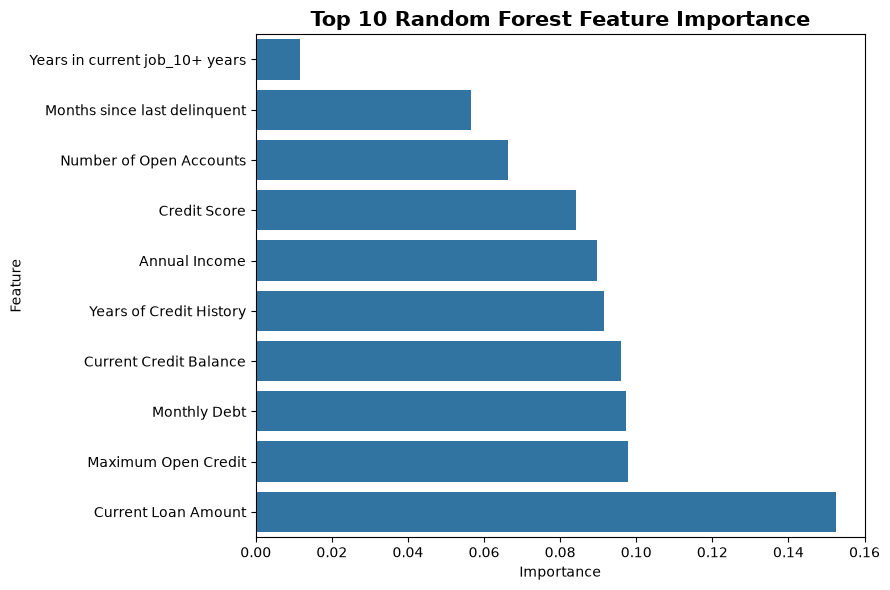

In [117]:
top_features = importance_df.head(10).copy()

# Remove preprocessing prefixes from feature names
top_features["Feature"] = (
    top_features["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

# Sort for horizontal bar chart
top_features = top_features.sort_values(
    by="Importance"
)

plt.figure(figsize=(9, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title(
    "Top 10 Random Forest Feature Importance",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("../Images/random_forest_feature_importance.png")

plt.show()

### Remarks

The visualization shows that Current Loan Amount has the highest feature importance in the Random Forest model, followed by Maximum Open Credit, Monthly Debt, and Current Credit Balance.

The results indicate that financial and credit-history variables contributed strongly to the model's predictions.

Feature importance reflects the model's use of these variables and should not be interpreted as evidence that they directly cause loan default.

## 7.32 Training the Final Model on the Full Training Dataset

Random Forest was selected as the final model based on its performance on the leakage-free validation set.

The final model is now trained using the complete cleaned training dataset so that all available labeled records can contribute to the final model before generating predictions for the test dataset.

A new preprocessing pipeline is fitted using the complete training data.

In [118]:
# Create a new preprocessing pipeline for the full training dataset

final_numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

final_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

final_preprocessor = ColumnTransformer(
    transformers=[
        ("num", final_numerical_transformer, numerical_features),
        ("cat", final_categorical_transformer, categorical_features)
    ]
)

# Fit preprocessing on the complete training data
X_full_processed = final_preprocessor.fit_transform(X)

print("Processed full training data shape:", X_full_processed.shape)

Processed full training data shape: (89785, 45)


In [119]:
# Train the final Random Forest

final_random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

final_random_forest.fit(X_full_processed, y)

print("Final Random Forest model trained successfully.")

Final Random Forest model trained successfully.


### Remarks

The final Random Forest model was trained using all 89,785 cleaned training records.

The preprocessing pipeline was fitted on the complete training dataset, producing 45 processed features.

This final model will be used to generate predictions for the provided test dataset, which does not contain the `Loan Status` target variable.

## 7.33 Preparing the Test Dataset

The test dataset does not contain the `Loan Status` target variable and will be used only for generating final predictions.

The same data-quality corrections applied to the training dataset are applied to the corresponding test features before preprocessing.

The test dataset is not used for model selection or evaluation.

In [120]:
test_clean = test.copy()

# Correct suspicious Credit Score values
test_clean.loc[
    test_clean["Credit Score"] > 850,
    "Credit Score"
] = (
    test_clean.loc[
        test_clean["Credit Score"] > 850,
        "Credit Score"
    ] / 10
)

# Replace placeholder Current Loan Amount values
test_clean["Current Loan Amount"] = test_clean[
    "Current Loan Amount"
].replace(99999999, np.nan)

print("Test dataset shape:", test_clean.shape)

Test dataset shape: (10353, 18)


## 7.34 Preprocessing the Test Dataset

The cleaned test features are transformed using the preprocessing pipeline fitted on the complete training dataset.

No preprocessing parameters are learned from the test dataset.

The resulting data will have the same feature structure used by the final Random Forest model.

In [121]:
# Select the same predictor columns used during training
X_test = test_clean[X.columns]

# Apply the fitted preprocessing pipeline
X_test_processed = final_preprocessor.transform(X_test)

print("Processed test data shape:", X_test_processed.shape)

Processed test data shape: (10353, 45)


## 7.35 Generating Final Loan Predictions

The final Random Forest model is used to generate predictions for all records in the test dataset.

The test dataset does not contain the actual `Loan Status`, so these predictions cannot be evaluated using accuracy, precision, recall, or F1-score.

The predictions represent the model's estimated loan outcome for each test record.

In [122]:
# Generate predictions for the test dataset
test_predictions = final_random_forest.predict(X_test_processed)

print("Predictions generated successfully.")
print("Number of predictions:", len(test_predictions))

Predictions generated successfully.
Number of predictions: 10353


## 7.36 Predicted Loan Status Distribution

The distribution of the predicted loan outcomes is examined to understand how the final Random Forest model classified the test records.

This is a descriptive check of the model's predictions. Since the test dataset does not contain the actual `Loan Status`, the predicted distribution cannot be used to measure model accuracy.

In [123]:
prediction_counts = pd.Series(test_predictions).value_counts().sort_index()

print("Predicted Fully Paid (0):", prediction_counts.get(0, 0))
print("Predicted Charged Off (1):", prediction_counts.get(1, 0))

Predicted Fully Paid (0): 9045
Predicted Charged Off (1): 1308


### Remarks

The final Random Forest model predicted 9,045 test records as Fully Paid and 1,308 records as Charged Off.

Approximately 12.63% of the test records were classified as Charged Off.

Since the test dataset does not contain the actual loan outcomes, this distribution is descriptive and cannot be used to calculate model accuracy.

## 7.37 Creating the Prediction Dataset

The model predictions are combined with the corresponding Loan ID and Customer ID from the test dataset.

The numeric predictions are converted back into their original loan-status labels:

- `0` → Fully Paid
- `1` → Charged Off

The resulting dataset will be saved as a CSV file for further use.

In [124]:
predictions_df = pd.DataFrame({
    "Loan ID": test_clean["Loan ID"],
    "Customer ID": test_clean["Customer ID"],
    "Predicted Loan Status": test_predictions
})

predictions_df["Predicted Loan Status"] = predictions_df[
    "Predicted Loan Status"
].map({
    0: "Fully Paid",
    1: "Charged Off"
})

print("Prediction dataset shape:", predictions_df.shape)

predictions_df.head()

Prediction dataset shape: (10353, 3)


,Loan ID,Customer ID,Predicted Loan Status
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,Fully Paid
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,Fully Paid
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,Fully Paid
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,Charged Off
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,Fully Paid


## 7.38 Saving the Prediction Results

The final loan predictions are saved as a CSV file.

The file contains the Loan ID, Customer ID, and the predicted loan status for all 10,353 test records.

In [125]:
import os

# Create an output folder if it does not already exist
os.makedirs("../outputs", exist_ok=True)

# Save predictions
predictions_df.to_csv(
    "../outputs/loan_predictions.csv",
    index=False
)

print("Prediction file saved successfully.")
print("File path: ../outputs/loan_predictions.csv")

Prediction file saved successfully.
File path: ../outputs/loan_predictions.csv


## 7.39 Verifying the Prediction File

The saved prediction file is loaded again to verify that it contains the expected number of records and columns.

This ensures that the final prediction results were saved correctly.

In [126]:
# Load the saved prediction file
saved_predictions = pd.read_csv("../outputs/loan_predictions.csv")

print("Saved prediction data shape:", saved_predictions.shape)
print("\nColumns:")
print(saved_predictions.columns.tolist())

print("\nFirst 5 records:")
saved_predictions.head()

Saved prediction data shape: (10353, 3)

Columns:
['Loan ID', 'Customer ID', 'Predicted Loan Status']

First 5 records:


,Loan ID,Customer ID,Predicted Loan Status
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,Fully Paid
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,Fully Paid
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,Fully Paid
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,Charged Off
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,Fully Paid


## 7.40 Final Prediction File Validation

The final prediction file is checked for missing values and unexpected prediction labels.

These checks confirm that every test record has a valid predicted loan status.

In [127]:
# Check for missing values
print("Missing values:")
print(saved_predictions.isnull().sum())

# Check predicted loan-status values
print("\nPredicted loan statuses:")
print(saved_predictions["Predicted Loan Status"].value_counts())

# Check number of records
print("\nNumber of records:", len(saved_predictions))

Missing values:
Loan ID                  353
Customer ID              353
Predicted Loan Status      0
dtype: int64

Predicted loan statuses:
Predicted Loan Status
Fully Paid     9045
Charged Off    1308
Name: count, dtype: int64

Number of records: 10353


## 7.41 Checking Blank Test Records

The prediction file contains missing Loan ID and Customer ID values for 353 records.

The original test dataset is checked to determine whether these records are completely blank.

Completely blank records should not be included in the final prediction output.

In [128]:
# Check for completely blank rows in the original test dataset
blank_test_rows = test.isna().all(axis=1).sum()

print("Completely blank test rows:", blank_test_rows)

Completely blank test rows: 353


## 7.42 Cleaning the Test Dataset

The original test dataset contains 353 completely blank records.

These records do not contain any loan information and therefore cannot represent valid prediction cases.

The blank records are removed before generating the final predictions.

In [129]:
# Remove completely blank rows from the test dataset
test_clean = test.dropna(how="all").copy()

print("Original test dataset shape:", test.shape)
print("Cleaned test dataset shape:", test_clean.shape)
print("Rows removed:", len(test) - len(test_clean))

Original test dataset shape: (10353, 18)
Cleaned test dataset shape: (10000, 18)
Rows removed: 353


## 7.43 Applying Test Data Quality Corrections

The same data-quality corrections applied during training-data preparation are applied to the cleaned test dataset.

Suspicious Credit Score values above 850 are scaled down by a factor of 10, and the placeholder value `99,999,999` in Current Loan Amount is treated as missing.

These corrections are applied before the test data is passed through the fitted preprocessing pipeline.

In [130]:
# Correct suspicious Credit Score values
test_clean.loc[
    test_clean["Credit Score"] > 850,
    "Credit Score"
] = (
    test_clean.loc[
        test_clean["Credit Score"] > 850,
        "Credit Score"
    ] / 10
)

# Replace placeholder Current Loan Amount values
test_clean["Current Loan Amount"] = test_clean[
    "Current Loan Amount"
].replace(99999999, np.nan)

print("Test data corrections applied successfully.")

Test data corrections applied successfully.
